In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt

import platform
from IPython.display import display, Markdown

# Import the cdk platereader module
# import cdk
# from cdk.instruments import platereader as pr

try:
    import cdk
    print("CDK already installed, skipping installation and restart.")
except ImportError:
    !pip install nucleus-cdk==0.6.2 -q > /dev/null 2>&1
    print("\nInstallation complete. Restarting runtime to refresh dependencies...")
    import os
    os._exit(0)

from cdk import logging
log = logging.setup_logging(logging.ERROR)

CDK already installed, skipping installation and restart.


In [ ]:
# Parameters
#data_file = "/mnt/instrument/biotek-cysteine/experiments/20261001-181311-cytation5-pure-timecourse-gfp-JM-MB-Mg-Osmo-Sweep.txt"
data_url = "https://data.nucleus.engineering/platereader/devstudio/20261001-181311-cytation5-pure-timecourse-gfp-JM-MB-Mg-Osmo-Sweep.txt"
platemap_file = None
platemap_url = "https://drive.google.com/file/d/1LybPWStJZuQV_b4cguMsLfphb3EghDhk/view?usp=sharing"


In [ ]:
# from cdk.instruments import platereader as pr

# # Load data
# result = pr.load_platereader_data(
#     data_file=data_url,
#     platemap_file=platemap_url,
#     platereader="biotek" # options: "biotek"
# )
import io
from cdk.lib.remote import read_text

sheet_id = "1D8dFjOUp3Yj6P-jjR9XKw77XcQ78D0539Raipp_paSI"
gid = "0"  # the tab holding the platemap
csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

result = pr.load_platereader_data(
    data_file=data_url,
    platemap_file=io.StringIO(read_text(csv_url)),
    platereader="biotek",
)

In [ ]:
desired_index = 0
data = result[desired_index]

In [ ]:
data.view()

,Date,Experiment,Well,Name,Type,Time,Data,Read,Read Name,Reader Type,Reader ID,Plate Type,Plate ID,Start Time,Read Modality,Gain,Excitation Wavelength (nm),Excitation Bandwidth (nm),Excitation Optics,Emission Wavelength (nm),Emission Bandwidth (nm),Emission Optics,Read Geometry,Read Height (mm)
0,2026-10-02,MB - MgSweepof preeincubation,I1,0-5µM AHSL,Sample,0 days 00:00:00,20,"GFP-G70:485,528",GFP-G70,Cytation5,1705168,Greiner 384 SV NoBind AutoMap,Plate 2,2026-10-01 18:22:15,Fluorescence,70,485,20,monochromator,528,20,monochromator,Top,10.5 mm
1,2026-10-02,MB - MgSweepof preeincubation,I1,0-5µM AHSL,Sample,0 days 00:05:00,35,"GFP-G70:485,528",GFP-G70,Cytation5,1705168,Greiner 384 SV NoBind AutoMap,Plate 2,2026-10-01 18:22:15,Fluorescence,70,485,20,monochromator,528,20,monochromator,Top,10.5 mm
2,2026-10-02,MB - MgSweepof preeincubation,I1,0-5µM AHSL,Sample,0 days 00:10:00,83,"GFP-G70:485,528",GFP-G70,Cytation5,1705168,Greiner 384 SV NoBind AutoMap,Plate 2,2026-10-01 18:22:15,Fluorescence,70,485,20,monochromator,528,20,monochromator,Top,10.5 mm
3,2026-10-02,MB - MgSweepof preeincubation,I1,0-5µM AHSL,Sample,0 days 00:15:00,164,"GFP-G70:485,528",GFP-G70,Cytation5,1705168,Greiner 384 SV NoBind AutoMap,Plate 2,2026-10-01 18:22:15,Fluorescence,70,485,20,monochromator,528,20,monochromator,Top,10.5 mm
4,2026-10-02,MB - MgSweepof preeincubation,I1,0-5µM AHSL,Sample,0 days 00:20:00,293,"GFP-G70:485,528",GFP-G70,Cytation5,1705168,Greiner 384 SV NoBind AutoMap,Plate 2,2026-10-01 18:22:15,Fluorescence,70,485,20,monochromator,528,20,monochromator,Top,10.5 mm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1163,2026-10-02,MB - MgSweepof preeincubation,J11,5,Sample,0 days 05:40:00,2583,"GFP-G70:485,528",GFP-G70,Cytation5,1705168,Greiner 384 SV NoBind AutoMap,Plate 2,2026-10-01 18:22:15,Fluorescence,70,485,20,monochromator,528,20,monochromator,Top,10.5 mm
1164,2026-10-02,MB - MgSweepof preeincubation,J11,5,Sample,0 days 05:45:00,2629,"GFP-G70:485,528",GFP-G70,Cytation5,1705168,Greiner 384 SV NoBind AutoMap,Plate 2,2026-10-01 18:22:15,Fluorescence,70,485,20,monochromator,528,20,monochromator,Top,10.5 mm
1165,2026-10-02,MB - MgSweepof preeincubation,J11,5,Sample,0 days 05:50:00,2608,"GFP-G70:485,528",GFP-G70,Cytation5,1705168,Greiner 384 SV NoBind AutoMap,Plate 2,2026-10-01 18:22:15,Fluorescence,70,485,20,monochromator,528,20,monochromator,Top,10.5 mm
1166,2026-10-02,MB - MgSweepof preeincubation,J11,5,Sample,0 days 05:55:00,2642,"GFP-G70:485,528",GFP-G70,Cytation5,1705168,Greiner 384 SV NoBind AutoMap,Plate 2,2026-10-01 18:22:15,Fluorescence,70,485,20,monochromator,528,20,monochromator,Top,10.5 mm


In [ ]:
exp = result.source_file.split("/")[-1]

rm = ""
for i, r in result.metadata.iterrows():
    rm += f"  - {r["Plate ID"]}: {r["Start Time"]}\n"

meta = f"""
# {exp}

**Runtime**
- Analysis host: {platform.node()}
- Python version: {platform.python_version()}
- CDK version: {cdk.__version__}

**Data**
- Data file: {result.source_file}
- Blocks: {len(result.data)}
- Metadata:
{rm}
"""

display(Markdown(meta))


# 20261001-181311-cytation5-pure-timecourse-gfp-JM-MB-Mg-Osmo-Sweep.txt

**Runtime**
- Analysis host: 611dfd688342
- Python version: 3.13.15
- CDK version: 0.6.2

**Data**
- Data file: https://data.nucleus.engineering/platereader/devstudio/20261001-181311-cytation5-pure-timecourse-gfp-JM-MB-Mg-Osmo-Sweep.txt
- Blocks: 2
- Metadata:
  - Plate 2: 2026-10-01 18:22:15



## Plot Raw Curves

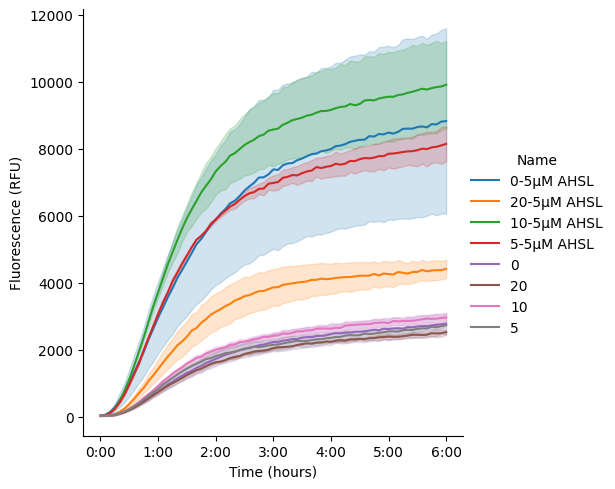

In [ ]:
data.plot()

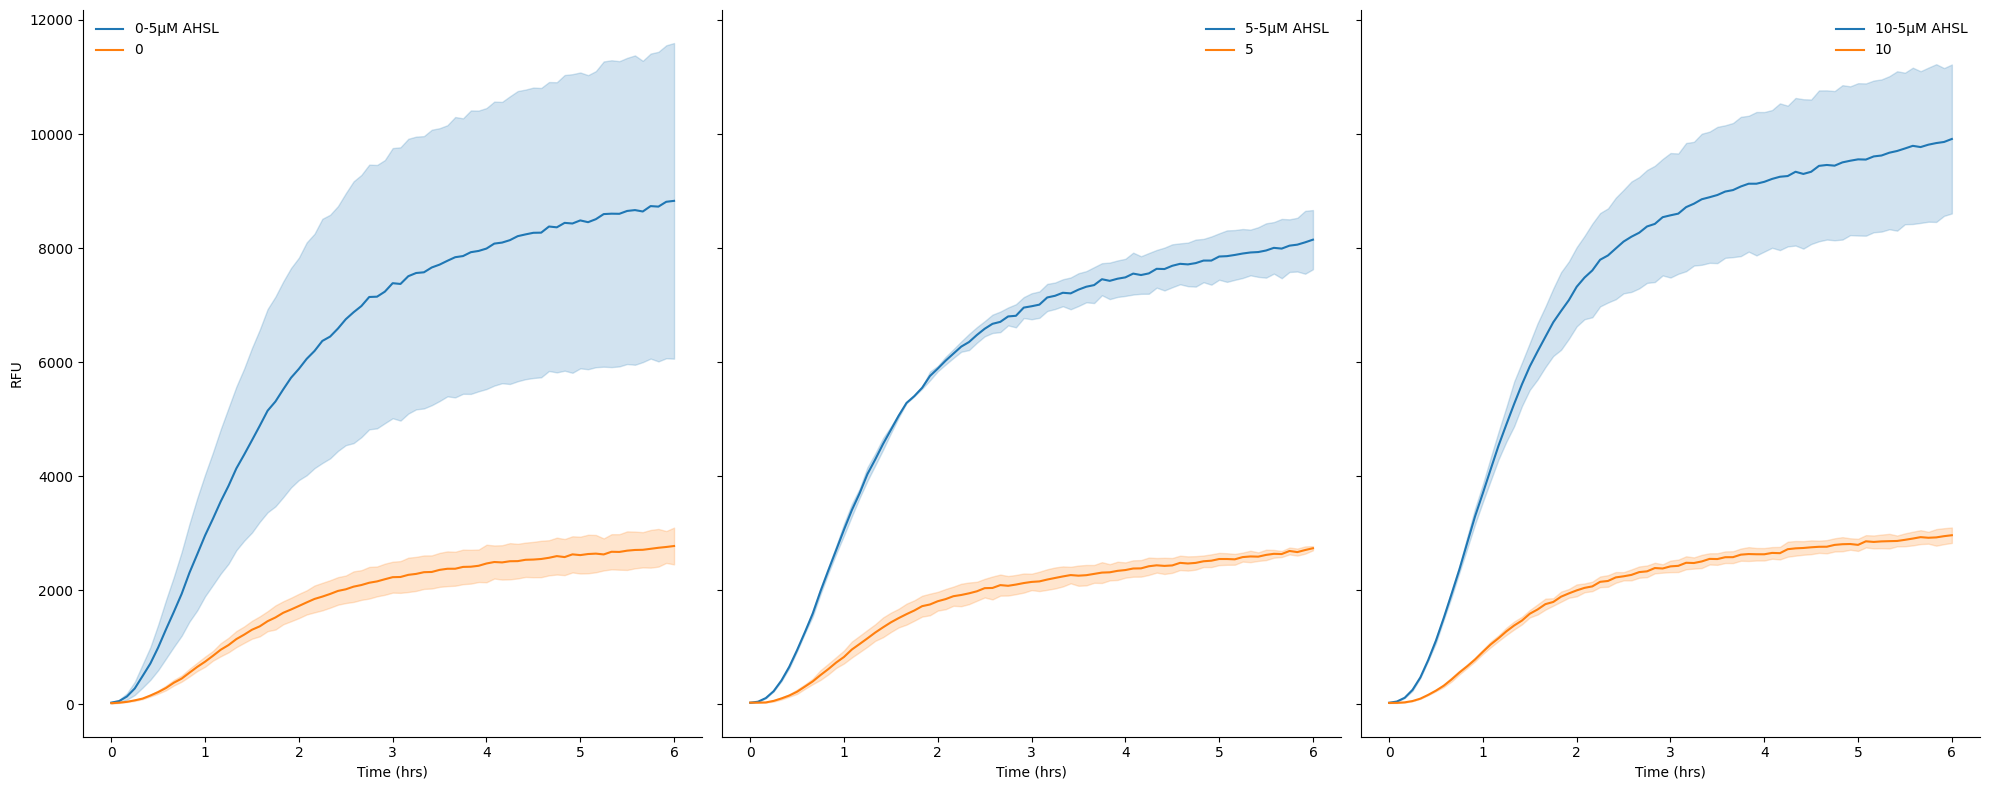

In [ ]:
#| label: mbcn-20261001-fig1

data_0 = data.select(name=["0-5µM AHSL", "0" ])
data_5 = data.select(name=["5-5µM AHSL", "5" ])
data_10 = data.select(name=["10-5µM AHSL", "10" ])

df_0 = data_0.data
df_5 = data_5.data
df_10 = data_10.data

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,8), sharey=True)

for df in [df_0, df_5, df_10]:
    df['Time_hrs'] = df['Time'].dt.total_seconds() / 3600

sns.lineplot(df_0, x="Time_hrs", y='Data', hue="Name", ax=ax1)
sns.lineplot(df_5, x="Time_hrs", y='Data', hue="Name", ax=ax2)
sns.lineplot(df_10, x="Time_hrs", y='Data', hue="Name", ax=ax3)

ax1.set(xlabel='Time (hrs)', ylabel='RFU')
ax2.set(xlabel='Time (hrs)', ylabel='RFU')
ax3.set(xlabel='Time (hrs)', ylabel='RFU')

for ax in [ax1, ax2, ax3]:
        ax.legend(frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

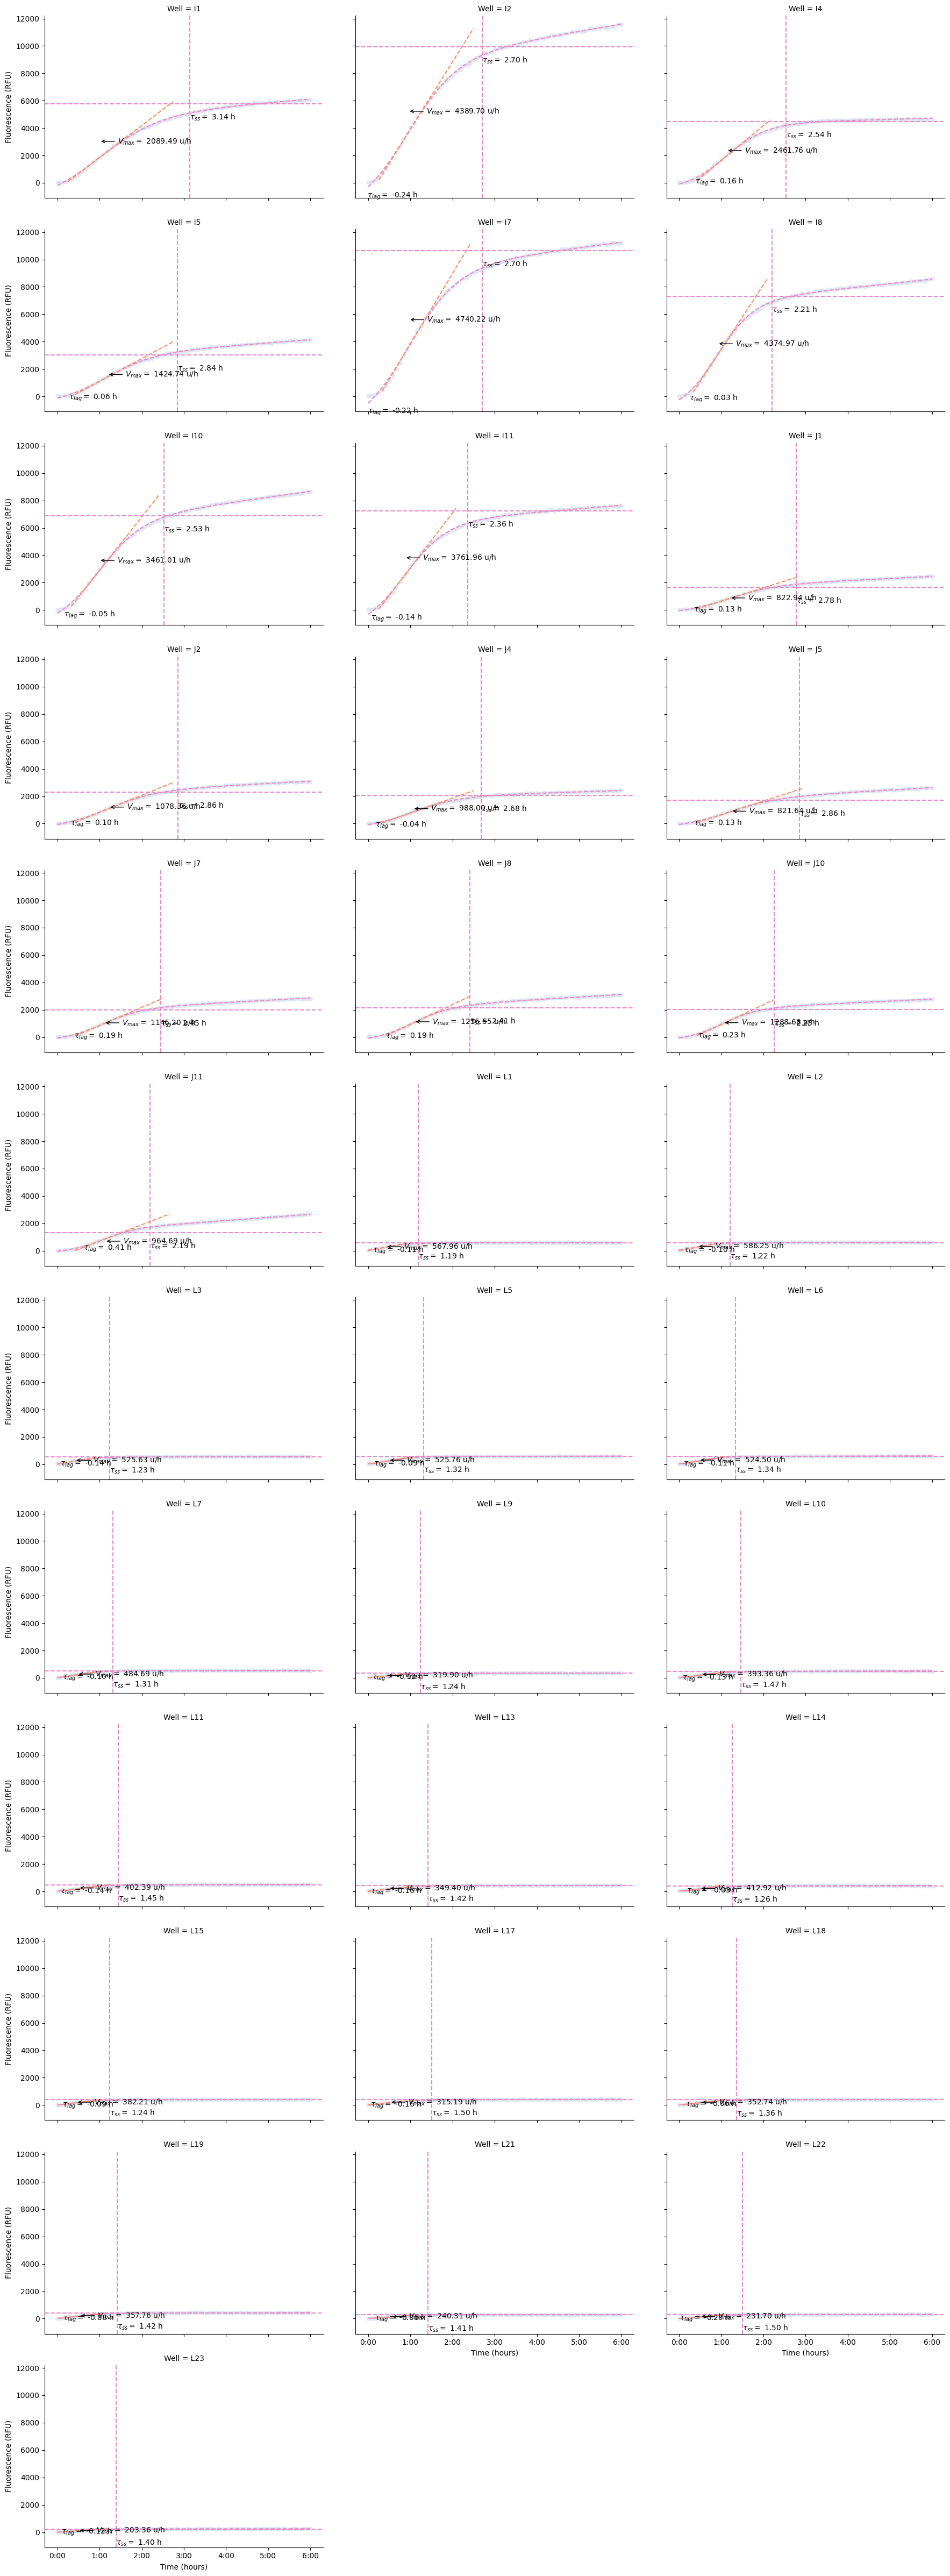

In [ ]:
g = kinetics.plot()

## Normalize Data
Now, use `data.normalize('<standard name>')` to normalize your data. This will calculate the average over a time window at the end of the experiment (by default, 1 hour), then divide all data by the mean of that window-average across all wells with the same `Name` (defined by your platemap).

In [ ]:
data.data["Well"].str.contains("B2").any()

np.False_

In [ ]:
if "Type" in data.columns and data.data["Type"].str.contains("Standard").any():
    # To check the exact name of your standard
    platemap = data.platemap
    standards = platemap[platemap['Type']=='Standard']
    standards['Name'].unique()

    data = data.normalize('10 uM HPTS')

    g = data.plot(style='Type', exclude_types=['Standard'])
else:
    print("Plate reader data does not contain labeled standards, skipping normalization.")

Plate reader data does not contain labeled standards, skipping normalization.


## Kinetic Analysis

See the [DevNote](https://devnotes.nucleus.engineering/articles/Newman-20260421) on kinetic analysis for more details.

**Metrics extracted:**

  - **Maximum velocity**: Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level
  - **Time-to-completion**: Time it takes to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit; "Good Fit" is `True` if $R^2 \geq 0.95$

In [ ]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = data.fit_kinetics()

In [ ]:
kinetics.summary

,Well,Max Velocity,Max Velocity Time,Lag Time,Steady State,Completion Time,Completion Threshold,Drift,Fit Function,R^2,Good Fit
0,I1,2089.49,0 days 01:00:06,-1 days +23:33:05,5758.00,0 days 03:08:13,0.95,246.34,sigmoid_drift,1.00,True
1,I2,4389.70,0 days 00:57:06,-1 days +23:45:39,9932.22,0 days 02:42:17,0.95,533.73,sigmoid_drift,1.00,True
2,I4,2461.76,0 days 01:07:26,0 days 00:09:49,4490.77,0 days 02:32:14,0.95,84.92,sigmoid_drift,1.00,True
3,I5,1424.74,0 days 01:11:13,0 days 00:03:43,3045.44,0 days 02:50:35,0.95,233.55,sigmoid_drift,1.00,True
4,I7,4740.22,0 days 00:57:39,-1 days +23:46:42,10651.64,0 days 02:42:07,0.95,400.05,sigmoid_drift,1.00,True
5,I8,4374.97,0 days 00:54:46,0 days 00:02:01,7307.49,0 days 02:12:25,0.95,331.38,sigmoid_drift,1.00,True
6,I10,3461.01,0 days 00:59:34,-1 days +23:56:48,6879.89,0 days 02:31:59,0.95,437.83,sigmoid_drift,1.00,True
7,I11,3761.96,0 days 00:52:12,-1 days +23:51:26,7237.49,0 days 02:21:38,0.95,250.51,sigmoid_drift,1.00,True
8,J1,822.94,0 days 01:12:11,0 days 00:08:03,1671.49,0 days 02:46:37,0.95,152.72,sigmoid_drift,1.00,True
9,J2,1078.36,0 days 01:13:09,0 days 00:06:09,2288.34,0 days 02:51:49,0.95,167.08,sigmoid_drift,1.00,True


## Visualize Fits

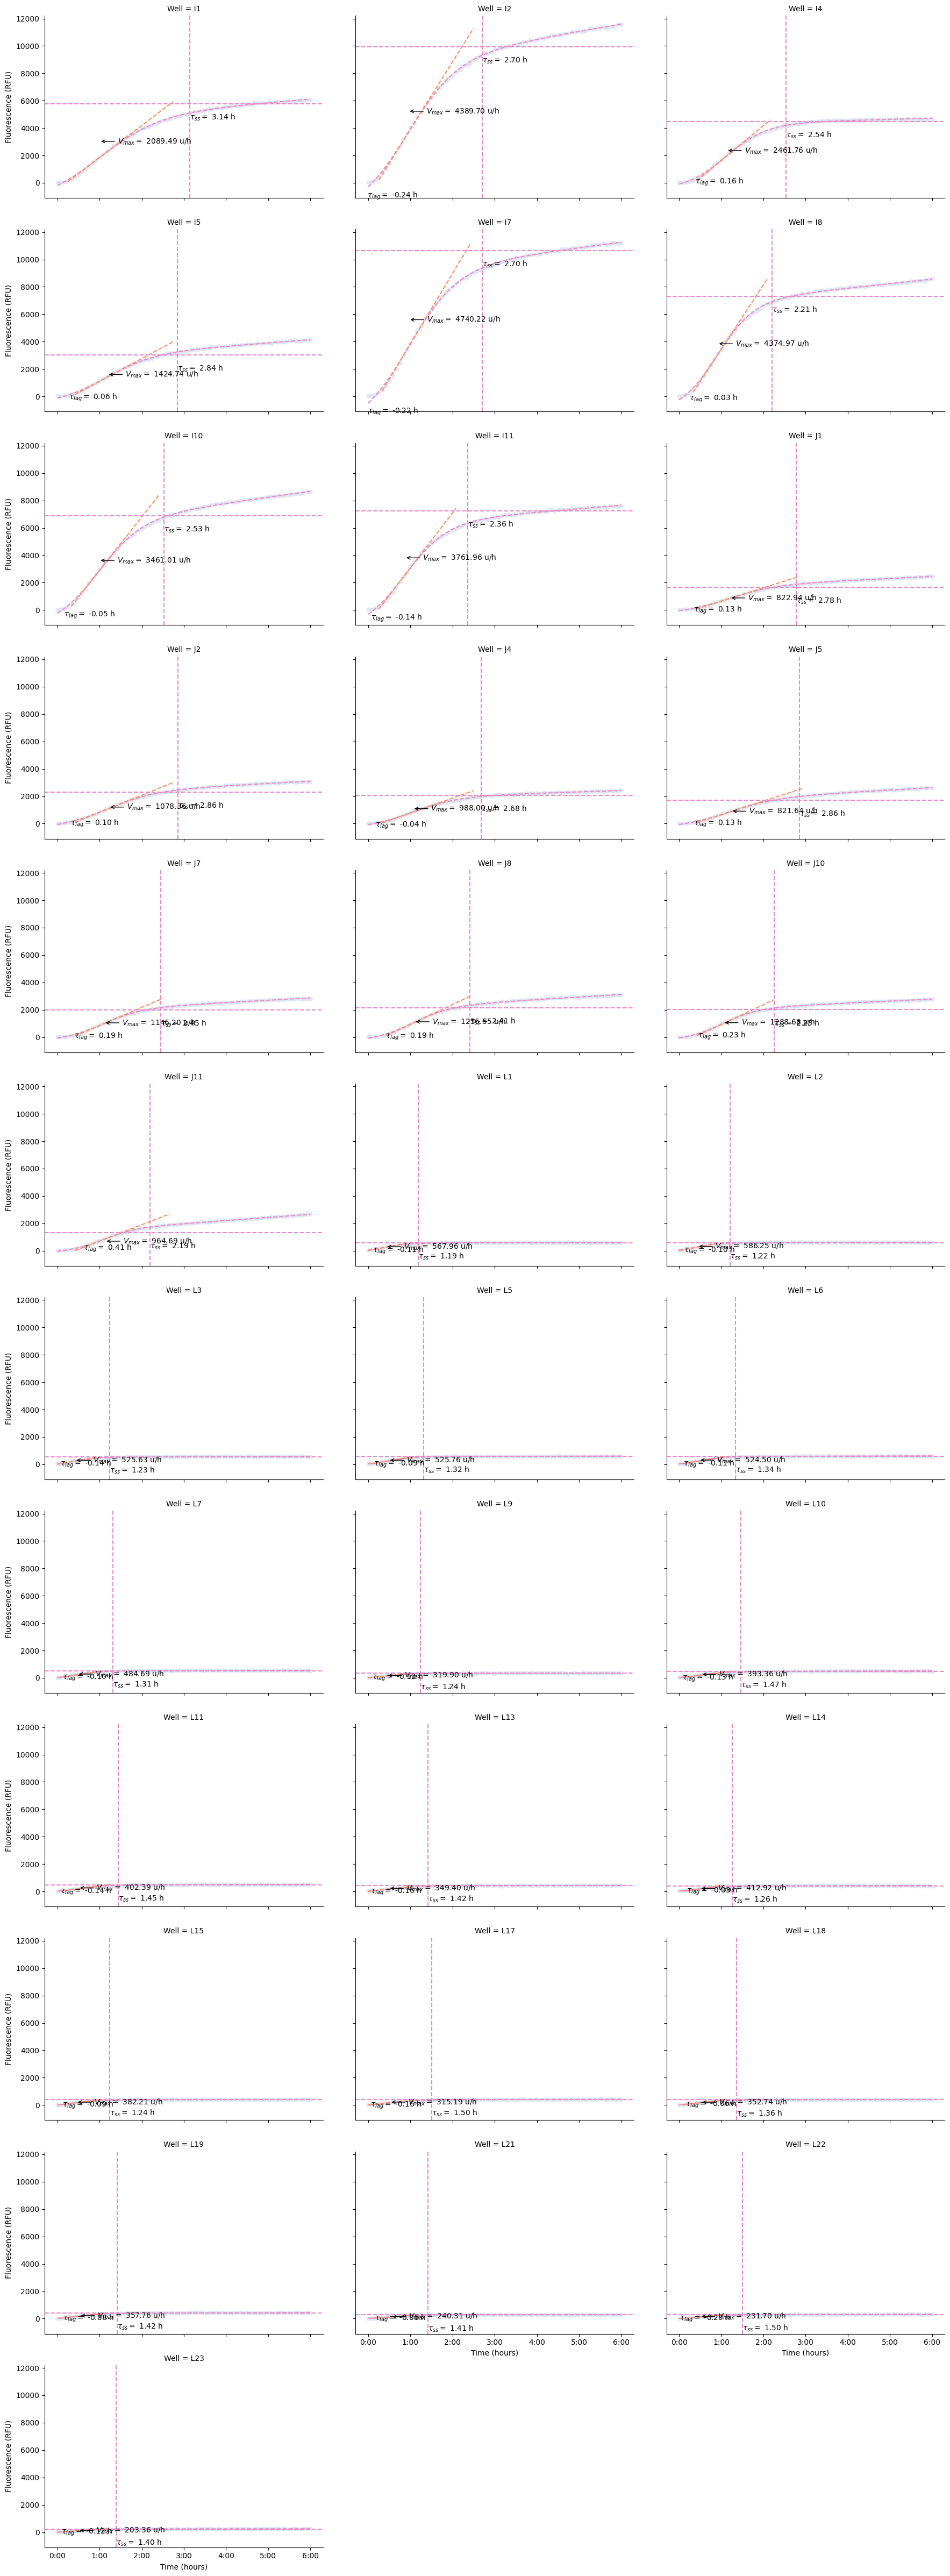

In [ ]:
g = kinetics.plot(col="Well")
# g = kinetics.plot() # call this to visualize across replicates

## Summary Plots

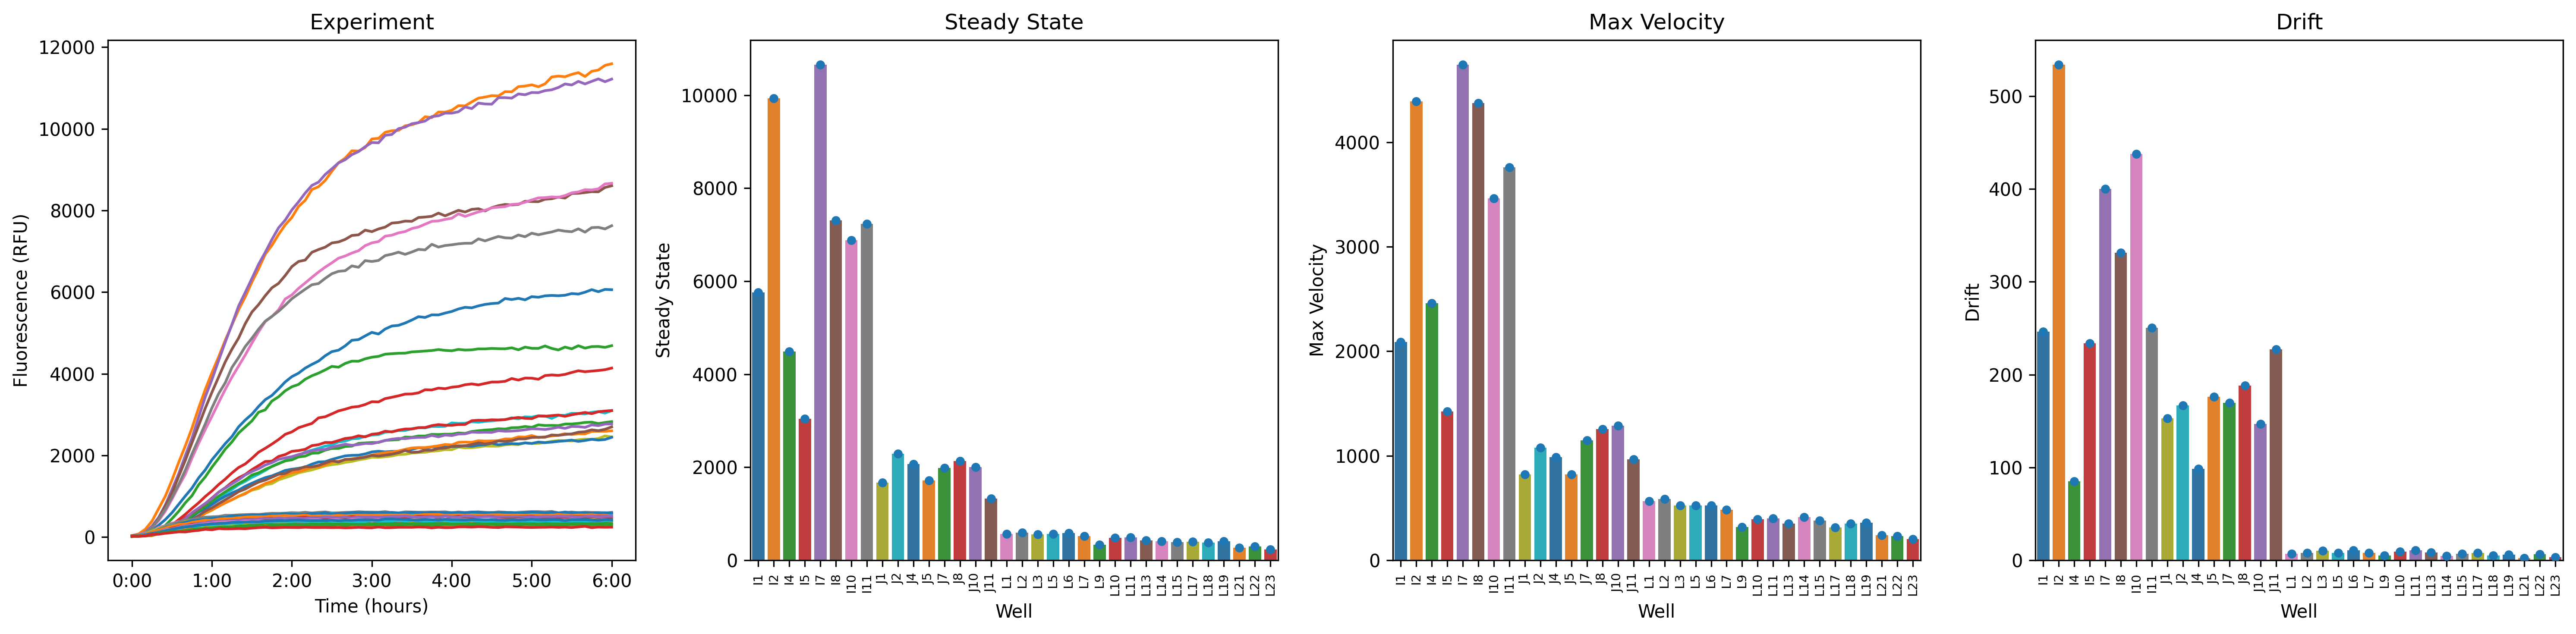

In [ ]:
g = kinetics.plot_summary()

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants